<a href="https://colab.research.google.com/github/Alaaeldinaly/final-ai-ml-project/blob/main/final_ai_ml_projec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

plt.style.use("ggplot")
sns.set_style("whitegrid")

In [3]:
print("Problem: Predict fraudulent online activity / transactions using machine learning.")
print("Task type: Classification")

Problem: Predict fraudulent online activity / transactions using machine learning.
Task type: Classification


In [4]:
data = fetch_openml("creditcard", version=1, as_frame=True)
df = data.frame.copy()

print("Dataset loaded successfully.")
print(df.shape)
print(df.head())

Dataset loaded successfully.
(284807, 30)
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V21       V22       V23       V24  \
0  0.098698  0.363787  0.090794  ... -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425 -0.166974  ... -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  0.207643  ...  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024 -0.054952  ... -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  0.753074  ... -0.009431  0.798278 -0.137458  0.141267   

        V25       V26     

In [5]:
print(df.info())
print(df.describe())
print(df.isnull().sum().sort_values(ascending=False).head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype   
---  ------  --------------   -----   
 0   V1      284807 non-null  float64 
 1   V2      284807 non-null  float64 
 2   V3      284807 non-null  float64 
 3   V4      284807 non-null  float64 
 4   V5      284807 non-null  float64 
 5   V6      284807 non-null  float64 
 6   V7      284807 non-null  float64 
 7   V8      284807 non-null  float64 
 8   V9      284807 non-null  float64 
 9   V10     284807 non-null  float64 
 10  V11     284807 non-null  float64 
 11  V12     284807 non-null  float64 
 12  V13     284807 non-null  float64 
 13  V14     284807 non-null  float64 
 14  V15     284807 non-null  float64 
 15  V16     284807 non-null  float64 
 16  V17     284807 non-null  float64 
 17  V18     284807 non-null  float64 
 18  V19     284807 non-null  float64 
 19  V20     284807 non-null  float64 
 20  V21     284807 non-null  f

In [6]:
y = df["Class"].astype(int)
X = df.drop(columns=["Class"])

print("Target distribution:")
print(y.value_counts())

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64


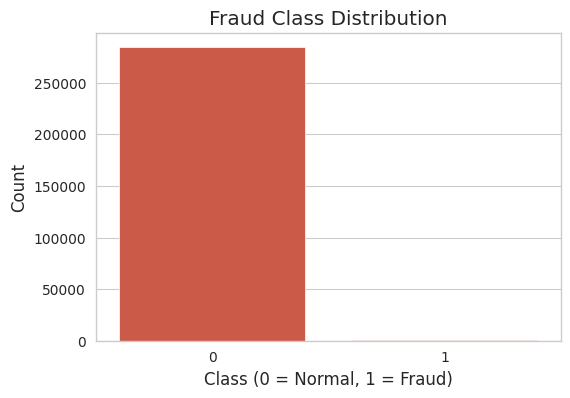

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Fraud Class Distribution")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

The dataset is highly imbalanced, which makes fraud detection more challenging and means accuracy alone is not enough.

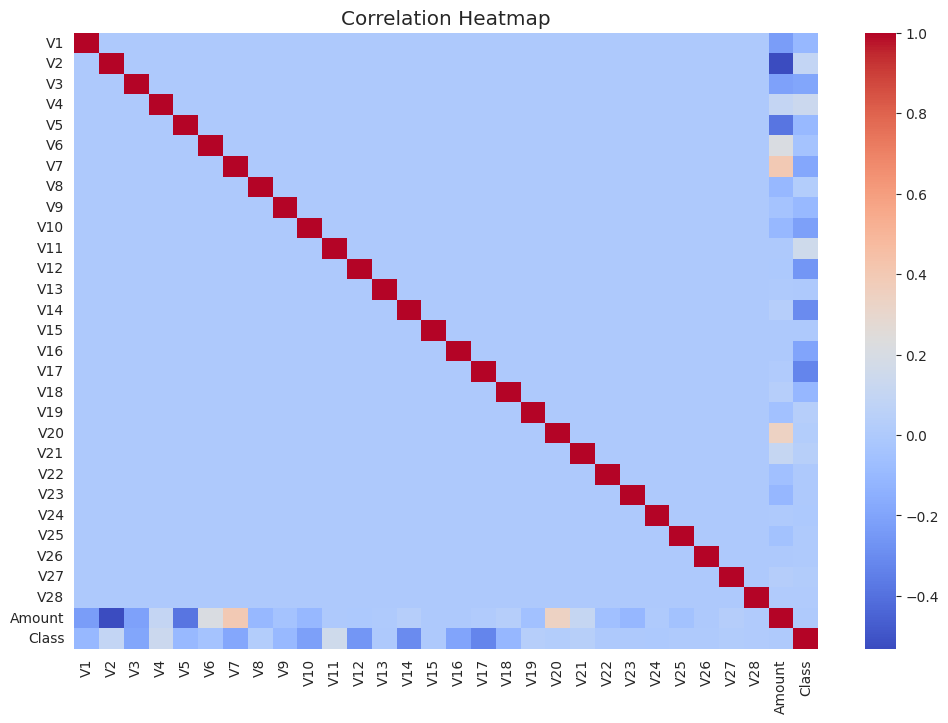

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

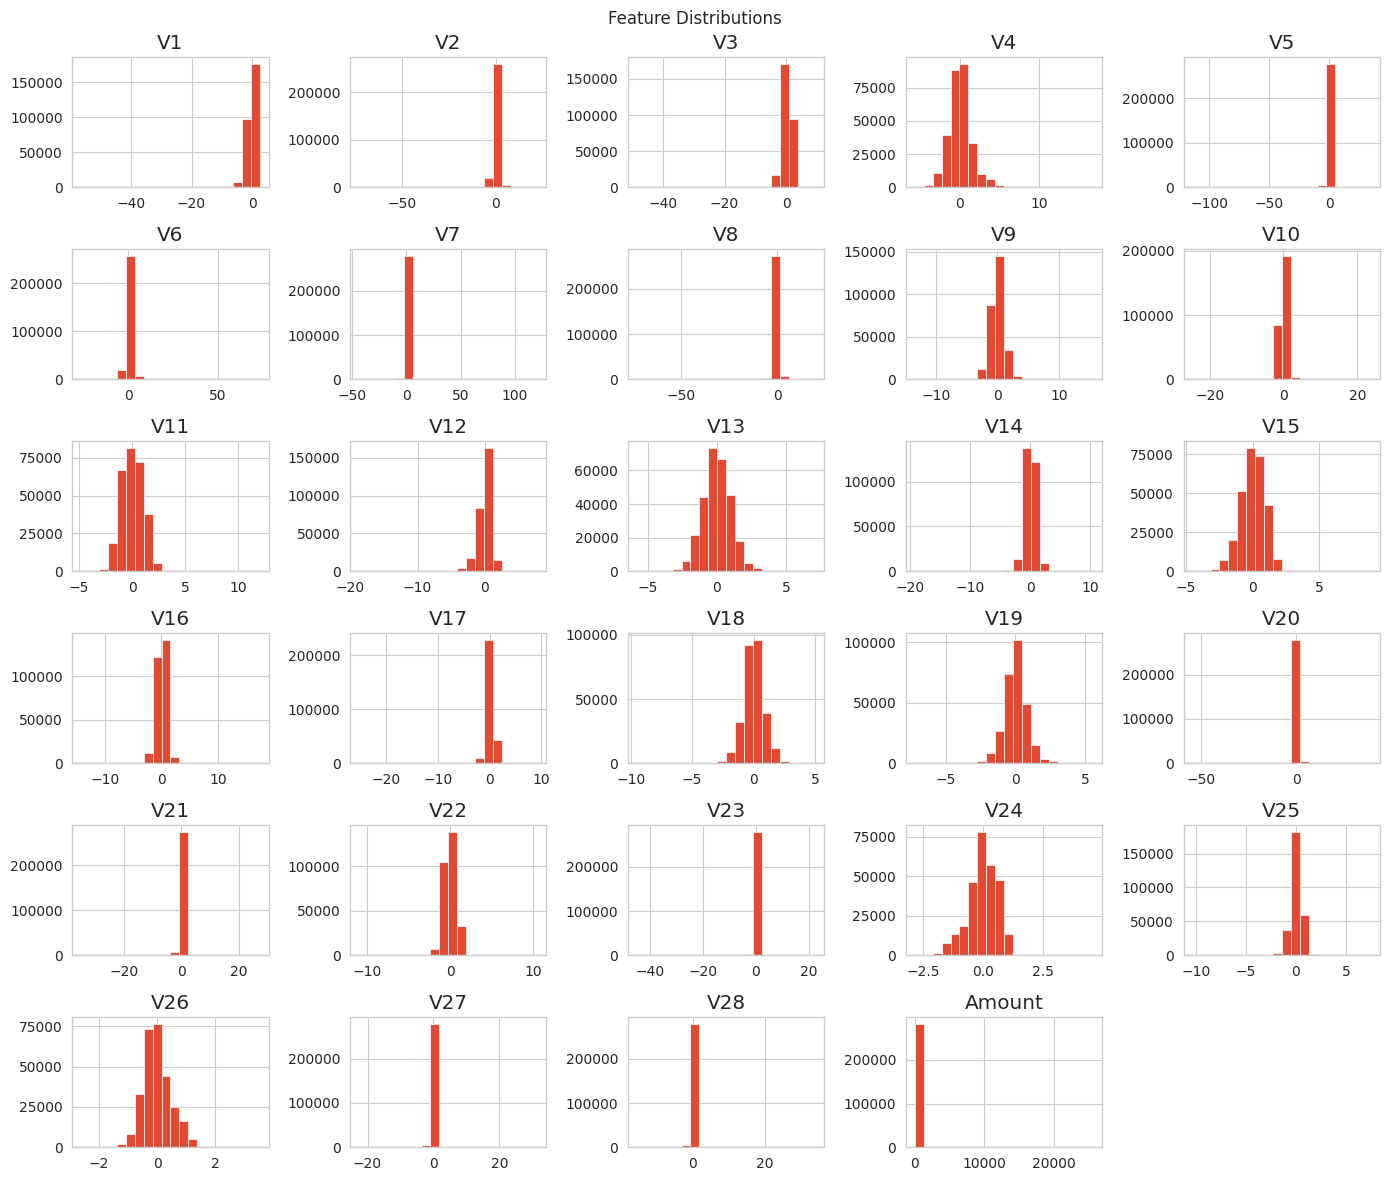

In [9]:
df.hist(figsize=(14, 12), bins=20)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (227845, 29)
X_test shape: (56962, 29)


In [11]:
numeric_cols = X.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols)
    ]
)

In [12]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

In [13]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("Logistic Regression Precision:", precision_score(y_test, log_pred))
print("Logistic Regression Recall:", recall_score(y_test, log_pred))
print("Logistic Regression F1-score:", f1_score(y_test, log_pred))
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, log_prob))

print("\nClassification Report:")
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.9991573329588147
Logistic Regression Precision: 0.8289473684210527
Logistic Regression Recall: 0.6428571428571429
Logistic Regression F1-score: 0.7241379310344828
Logistic Regression ROC-AUC: 0.957816286334455

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [14]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [15]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest Precision:", precision_score(y_test, rf_pred))
print("Random Forest Recall:", recall_score(y_test, rf_pred))
print("Random Forest F1-score:", f1_score(y_test, rf_pred))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9993504441557529
Random Forest Precision: 0.8080808080808081
Random Forest Recall: 0.8163265306122449
Random Forest F1-score: 0.8121827411167513
Random Forest ROC-AUC: 0.9831906489382473

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.82      0.81        98

    accuracy                           1.00     56962
   macro avg       0.90      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



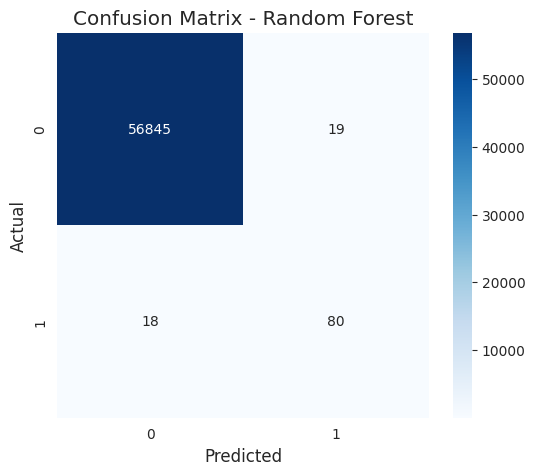

In [16]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

print("Cross-validation F1 scores:", rf_cv_scores)
print("Mean CV F1 score:", rf_cv_scores.mean())

Cross-validation F1 scores: [0.825      0.78431373 0.85365854]
Mean CV F1 score: 0.8209907540251873


In [18]:
param_grid = {
    "classifier__n_estimators": [100],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2],
    "classifier__min_samples_leaf": [1]
}

grid_search = GridSearchCV(
    rf_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

Best Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


In [19]:
best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:, 1]

print("Best Model Accuracy:", accuracy_score(y_test, best_pred))
print("Best Model Precision:", precision_score(y_test, best_pred))
print("Best Model Recall:", recall_score(y_test, best_pred))
print("Best Model F1-score:", f1_score(y_test, best_pred))
print("Best Model ROC-AUC:", roc_auc_score(y_test, best_prob))

print("\nClassification Report:")
print(classification_report(y_test, best_pred))

Best Model Accuracy: 0.9995259997893332
Best Model Precision: 0.961038961038961
Best Model Recall: 0.7551020408163265
Best Model F1-score: 0.8457142857142858
Best Model ROC-AUC: 0.9580056030572047

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [20]:
rf_best = best_model.named_steps["classifier"]
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_best.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(15))

        Feature  Importance
3       num__V4    0.149389
9      num__V10    0.148011
13     num__V14    0.138487
11     num__V12    0.091651
10     num__V11    0.087428
16     num__V17    0.060092
6       num__V7    0.046490
2       num__V3    0.046122
15     num__V16    0.037471
1       num__V2    0.017206
20     num__V21    0.014569
17     num__V18    0.014230
28  num__Amount    0.012693
18     num__V19    0.012583
8       num__V9    0.011733


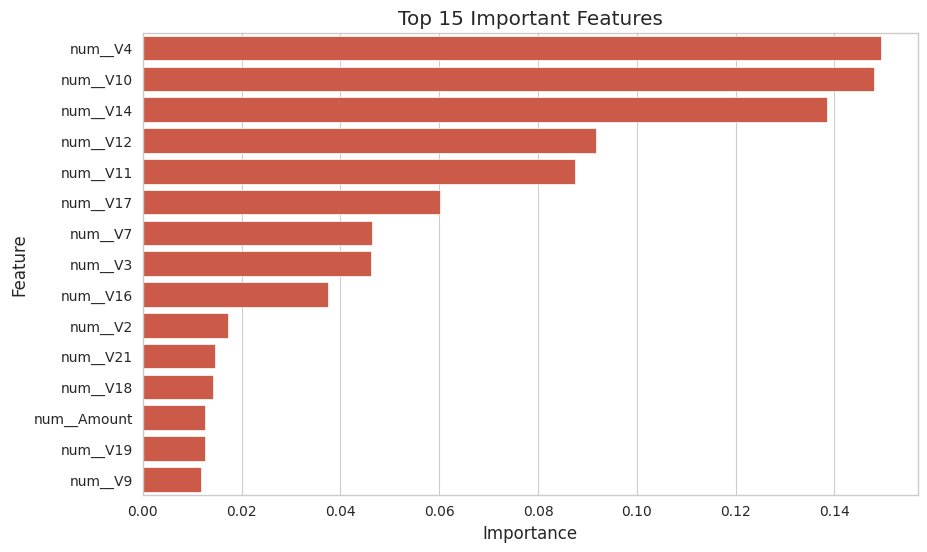

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature")
plt.title("Top 15 Important Features")
plt.show()

In [22]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Tuned Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, best_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, best_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, best_pred)
    ],
    "F1-score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, best_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, best_prob)
    ]
})

print(comparison_df)

                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0  Logistic Regression  0.999157   0.828947  0.642857  0.724138  0.957816
1        Random Forest  0.999350   0.808081  0.816327  0.812183  0.983191
2  Tuned Random Forest  0.999526   0.961039  0.755102  0.845714  0.958006


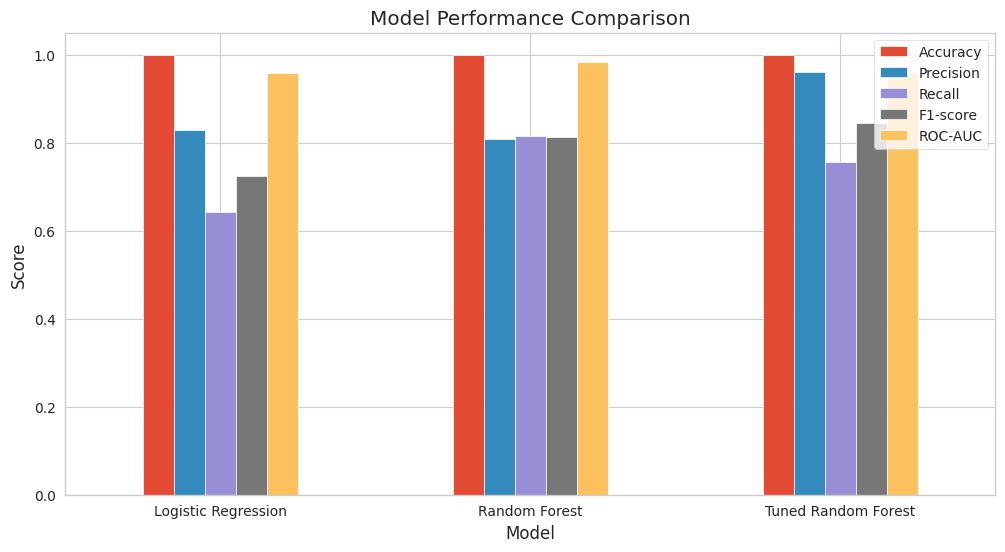

In [23]:
comparison_df.set_index("Model").plot(kind="bar", figsize=(12, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.show()

In [24]:
def predict_transaction(features_dict):
    input_df = pd.DataFrame([features_dict])
    prediction = best_model.predict(input_df)[0]
    probability = best_model.predict_proba(input_df)[0][1]

    if prediction == 1:
        print("Prediction: Fraudulent Transaction")
    else:
        print("Prediction: Normal Transaction")

    print("Fraud Probability:", probability)

sample_input = X_test.iloc[0].to_dict()
predict_transaction(sample_input)

Prediction: Normal Transaction
Fraud Probability: 0.0


In [25]:
sample_case = X_test.iloc[1].to_dict()
print("Input sample:")
print(sample_case)

predict_transaction(sample_case)

Input sample:
{'V1': -2.82981594327279, 'V2': -2.76514921229269, 'V3': 2.53779295063997, 'V4': -1.07458042259191, 'V5': 2.84255889292598, 'V6': -2.15353644367205, 'V7': -1.79551885720369, 'V8': -0.250020372324704, 'V9': 3.07350426338358, 'V10': -1.00041794567463, 'V11': 1.85084176033081, 'V12': -1.54977887088034, 'V13': 1.25233673695303, 'V14': 0.963974373307274, 'V15': -0.481027223791626, 'V16': -0.14731917203129, 'V17': -0.209328171581066, 'V18': 1.05889790297841, 'V19': 0.397056508186649, 'V20': -0.515764693656115, 'V21': -0.295554564490287, 'V22': 0.109304966698836, 'V23': -0.81327196874425, 'V24': 0.0429955726118499, 'V25': -0.0276596849389052, 'V26': -0.910247054904536, 'V27': 0.110801759066737, 'V28': -0.511938134872381, 'Amount': 11.85}
Prediction: Normal Transaction
Fraud Probability: 0.0


# Business Recommendations

Based on the model findings:

- Transactions flagged as high fraud risk should be reviewed before approval
- The institution should use the model as an early warning system
- High-risk patterns from important features should be monitored in real time
- Because fraud data is imbalanced, focus should be placed on recall and F1-score rather than accuracy alone
- The model should be retrained regularly as fraud patterns evolve

# Conclusion

This project addressed a real-world fraud detection problem using machine learning.

Main steps completed:
- loaded and explored the dataset
- handled preprocessing and scaling
- trained multiple models
- tuned hyperparameters using GridSearchCV
- evaluated performance using classification metrics
- analyzed important features
- deployed the final model in a simple interactive way inside Colab

The tuned Random Forest model provided the strongest balance between predictive performance and interpretability for this task.